# Logistics Operations — Analysis
**Project:** Logistics Capstone  
**Notebook:** 03 — Analysis & Visualizations  
**Tools:** pandas, matplotlib, seaborn  

---
**Three analysis questions:**
1. Driver performance — on-time rate, MPG, revenue per mile
2. Route profitability — revenue vs fuel cost by lane
3. Fleet health — truck utilization and maintenance cost per mile

## 1. Import libraries and load clean data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Use a clean visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

EXPORT_PATH = '../exports/'

# Load clean exports
trips            = pd.read_csv(EXPORT_PATH + 'trips_clean.csv')
fuel             = pd.read_csv(EXPORT_PATH + 'fuel_purchases_clean.csv')
safety           = pd.read_csv(EXPORT_PATH + 'safety_incidents_clean.csv')
drivers          = pd.read_csv(EXPORT_PATH + 'drivers.csv')
trucks           = pd.read_csv(EXPORT_PATH + 'trucks.csv')
loads            = pd.read_csv(EXPORT_PATH + 'loads.csv')
routes           = pd.read_csv(EXPORT_PATH + 'routes.csv')
customers        = pd.read_csv(EXPORT_PATH + 'customers.csv')
delivery_events  = pd.read_csv(EXPORT_PATH + 'delivery_events.csv')
maintenance      = pd.read_csv(EXPORT_PATH + 'maintenance_records.csv')
driver_metrics   = pd.read_csv(EXPORT_PATH + 'driver_monthly_metrics.csv')
truck_metrics    = pd.read_csv(EXPORT_PATH + 'truck_utilization_metrics.csv')

print('All clean tables loaded.')

Matplotlib is building the font cache; this may take a moment.


All clean tables loaded.


---
## Analysis 1 — Driver Performance

**Question:** Which drivers have the best on-time rate, fuel efficiency, and revenue per mile?  
**Tables used:** `trips` + `delivery_events` + `loads` + `drivers`

### 1a. On-time rate per driver

We join `delivery_events` (which has `on_time_flag`) to `trips` (which has `driver_id`),  
then group by driver and calculate what % of deliveries were on time.

This is exactly like a SQL `JOIN ... GROUP BY`.

In [2]:
# Keep only delivery events (not pickups) to avoid double counting
# Check what event types exist first
print('Delivery event types:')
print(delivery_events.columns.tolist())
print()
print(delivery_events.head(3))

Delivery event types:
['event_id', 'load_id', 'trip_id', 'event_type', 'facility_id', 'scheduled_datetime', 'actual_datetime', 'detention_minutes', 'on_time_flag', 'location_city', 'location_state']

      event_id       load_id       trip_id event_type facility_id  \
0  EVT00000001  LOAD00000001  TRIP00000001     Pickup    FAC00034   
1  EVT00000002  LOAD00000001  TRIP00000001   Delivery    FAC00046   
2  EVT00000003  LOAD00000002  TRIP00000002     Pickup    FAC00015   

           scheduled_datetime             actual_datetime  detention_minutes  \
0  2022-01-01 18:00:00.000000  2022-01-01 20:58:55.918185                  0   
1  2022-01-02 23:10:55.918185  2022-01-02 21:30:22.142060                230   
2  2022-01-01 18:00:00.000000  2022-01-01 17:37:26.608430                 62   

   on_time_flag location_city location_state  
0         False       Houston             TX  
1          True       Detroit             MI  
2          True   Kansas City             MO  


In [3]:
# Join delivery_events to trips to get driver_id
events_trips = pd.merge(
    delivery_events,
    trips[['trip_id', 'driver_id']],
    on='trip_id',
    how='inner'
)

print(f'Merged shape: {events_trips.shape}')
print(events_trips[['trip_id', 'driver_id', 'on_time_flag']].head())

Merged shape: (160916, 12)
        trip_id driver_id  on_time_flag
0  TRIP00000001  DRV00117         False
1  TRIP00000001  DRV00117          True
2  TRIP00000002  DRV00141          True
3  TRIP00000002  DRV00141         False
4  TRIP00000003  DRV00032          True


In [4]:
# Calculate on-time rate per driver
# on_time_flag is True/False — mean() gives us the proportion
ontime_by_driver = (
    events_trips
    .groupby('driver_id')['on_time_flag']
    .agg(total_deliveries='count', on_time_rate='mean')
    .reset_index()
)

ontime_by_driver['on_time_rate'] = (ontime_by_driver['on_time_rate'] * 100).round(1)

# Filter to drivers with at least 50 deliveries for reliability
ontime_by_driver = ontime_by_driver[ontime_by_driver['total_deliveries'] >= 50]
ontime_by_driver = ontime_by_driver.sort_values('on_time_rate', ascending=False)

print(f'Drivers with 50+ deliveries: {len(ontime_by_driver)}')
print()
print('Top 10 drivers by on-time rate:')
print(ontime_by_driver.head(10).to_string(index=False))

Drivers with 50+ deliveries: 124

Top 10 drivers by on-time rate:
driver_id  total_deliveries  on_time_rate
 DRV00108              1388         58.80
 DRV00038              1346         58.70
 DRV00138              1314         58.40
 DRV00112              1204         58.30
 DRV00002              1264         58.20
 DRV00039              1308         58.00
 DRV00020              1324         57.90
 DRV00089              1278         57.90
 DRV00100              1332         57.80
 DRV00034              1220         57.80


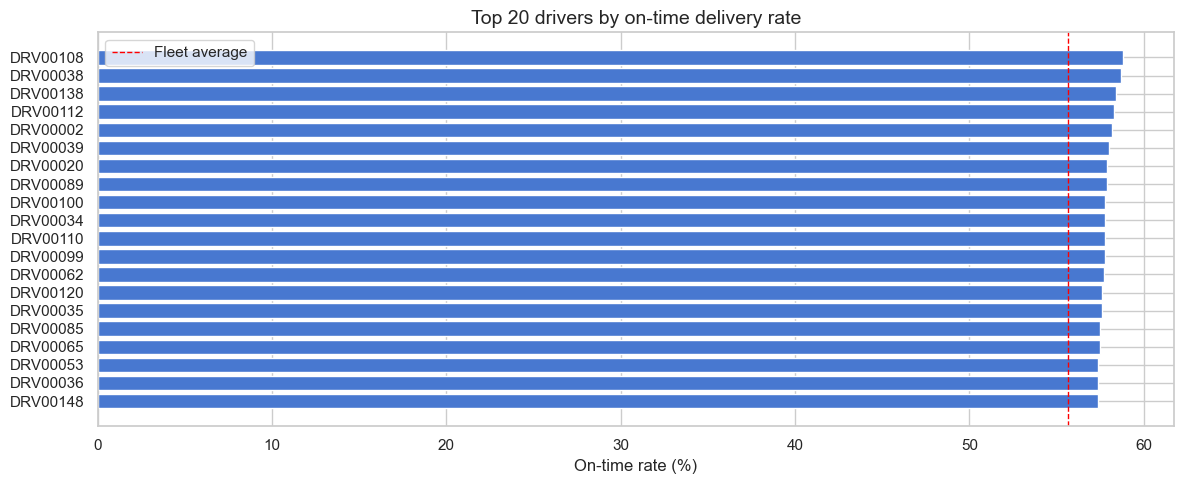

Fleet average on-time rate: 55.7%


In [5]:
# Chart: Top 20 drivers by on-time rate
top20_ontime = ontime_by_driver.head(20)

fig, ax = plt.subplots()
bars = ax.barh(
    top20_ontime['driver_id'].astype(str),
    top20_ontime['on_time_rate'],
    color=sns.color_palette('muted')[0]
)
ax.set_xlabel('On-time rate (%)')
ax.set_title('Top 20 drivers by on-time delivery rate')
ax.axvline(x=ontime_by_driver['on_time_rate'].mean(), color='red',
           linestyle='--', linewidth=1, label='Fleet average')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../exports/chart_driver_ontime.png', dpi=150)
plt.show()
print(f'Fleet average on-time rate: {ontime_by_driver["on_time_rate"].mean():.1f}%')

### 1b. Fuel efficiency (MPG) per driver

In [6]:
# Check trips columns for distance and fuel
print('Trips columns:')
print(trips.columns.tolist())

Trips columns:
['trip_id', 'load_id', 'driver_id', 'truck_id', 'trailer_id', 'dispatch_date', 'actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'trip_status']


In [8]:
# Group trips by driver — sum miles and fuel, then calculate MPG
# Update column names below if yours differ from actual_miles / fuel_used_gallons
mpg_by_driver = (
    trips
    .groupby('driver_id')
    .agg(
        total_miles = ('actual_distance_miles', 'sum'),
        total_fuel  = ('fuel_gallons_used', 'sum'),
        avg_mpg     = ('average_mpg', 'mean'),
        trip_count  = ('trip_id', 'count')
    )
    .reset_index()
)

mpg_by_driver['avg_mpg'] = mpg_by_driver['avg_mpg'].round(2)
mpg_by_driver = mpg_by_driver[mpg_by_driver['trip_count'] >= 20]
mpg_by_driver = mpg_by_driver.sort_values('avg_mpg', ascending=False)

print('Top 10 drivers by MPG:')
print(mpg_by_driver[['driver_id', 'total_miles', 'total_fuel', 'avg_mpg', 'trip_count']].head(10).to_string(index=False))


Top 10 drivers by MPG:
driver_id  total_miles  total_fuel  avg_mpg  trip_count
 DRV00105       943525  144,814.80     6.57         651
 DRV00109       921801  140,899.40     6.57         635
 DRV00103       930822  143,535.20     6.56         641
 DRV00003       960714  148,063.70     6.55         646
 DRV00098       938818  144,823.70     6.55         656
 DRV00049       859233  132,960.40     6.55         600
 DRV00141       928130  143,009.60     6.55         640
 DRV00023       946983  145,672.20     6.55         670
 DRV00057       874343  134,472.20     6.55         611
 DRV00064       840201  129,349.90     6.54         589


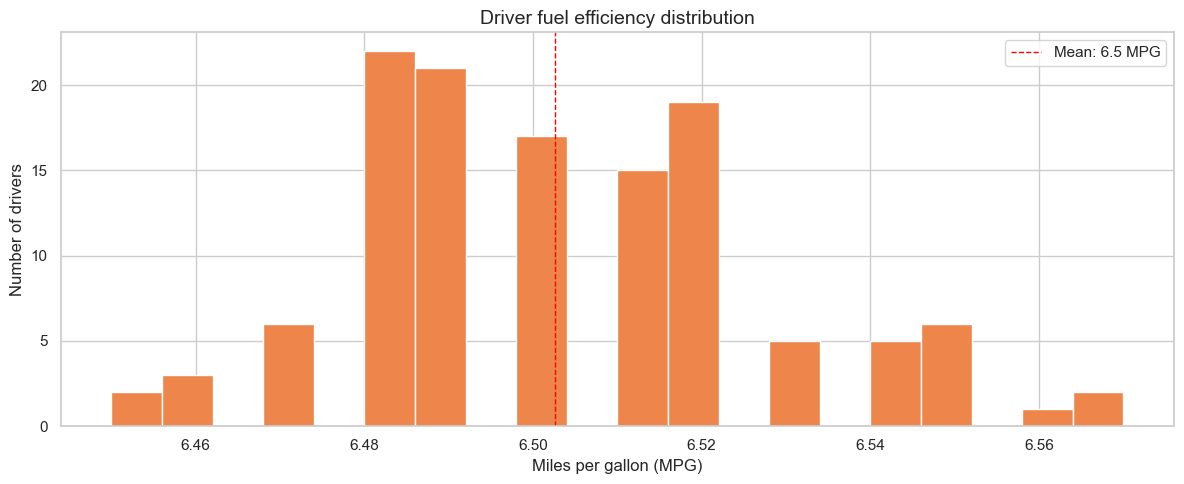

In [10]:
# Chart: MPG distribution across all drivers
fig, ax = plt.subplots()
ax.hist(mpg_by_driver['avg_mpg'], bins=20, color=sns.color_palette('muted')[1], edgecolor='white')
ax.axvline(x=mpg_by_driver['avg_mpg'].mean(), color='red',
           linestyle='--', linewidth=1, label=f'Mean: {mpg_by_driver["avg_mpg"].mean():.1f} MPG')
ax.set_xlabel('Miles per gallon (MPG)')
ax.set_ylabel('Number of drivers')
ax.set_title('Driver fuel efficiency distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../exports/chart_driver_mpg.png', dpi=150)
plt.show()

### 1c. Revenue per mile per driver

In [11]:
# Check loads columns for revenue
print('Loads columns:')
print(loads.columns.tolist())

Loads columns:
['load_id', 'customer_id', 'route_id', 'load_date', 'load_type', 'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge', 'accessorial_charges', 'load_status', 'booking_type']


In [13]:
# Join trips to loads to get revenue, then group by driver
trips_loads = pd.merge(
    trips[['trip_id', 'driver_id', 'actual_distance_miles', 'load_id']],
    loads[['load_id', 'revenue']],
    on='load_id',
    how='inner'
)

rev_by_driver = (
    trips_loads
    .groupby('driver_id')
    .agg(
        total_revenue = ('revenue', 'sum'),
        total_miles   = ('actual_distance_miles', 'sum'),
        trips         = ('trip_id', 'count')
    )
    .reset_index()
)

rev_by_driver['revenue_per_mile'] = (rev_by_driver['total_revenue'] / rev_by_driver['total_miles']).round(2)
rev_by_driver = rev_by_driver[rev_by_driver['trips'] >= 20]
rev_by_driver = rev_by_driver.sort_values('revenue_per_mile', ascending=False)

print('Top 10 drivers by revenue per mile:')
print(rev_by_driver[['driver_id', 'total_revenue', 'total_miles', 'revenue_per_mile']].head(10).to_string(index=False))

Top 10 drivers by revenue per mile:
driver_id  total_revenue  total_miles  revenue_per_mile
 DRV00101   2,036,807.23       923075              2.21
 DRV00002   1,974,243.85       898133              2.20
 DRV00005   1,923,062.63       873616              2.20
 DRV00057   1,910,792.38       874343              2.19
 DRV00033   2,021,174.50       923838              2.19
 DRV00091   1,817,699.40       834155              2.18
 DRV00016   2,184,612.27      1001647              2.18
 DRV00056   2,057,237.23       944481              2.18
 DRV00099   2,071,446.50       950305              2.18
 DRV00105   2,044,399.95       943525              2.17


### 1d. Export driver performance summary

In [14]:
# Combine on-time, MPG, and revenue into one driver summary table
driver_summary = (
    ontime_by_driver[['driver_id', 'total_deliveries', 'on_time_rate']]
    .merge(mpg_by_driver[['driver_id', 'total_miles', 'avg_mpg']], on='driver_id', how='inner')
    .merge(rev_by_driver[['driver_id', 'total_revenue', 'revenue_per_mile']], on='driver_id', how='inner')
)

driver_summary = driver_summary.sort_values('on_time_rate', ascending=False)

print(f'Driver summary: {driver_summary.shape[0]} drivers')
print(driver_summary.head(10).to_string(index=False))

driver_summary.to_csv(EXPORT_PATH + 'analysis_driver_performance.csv', index=False)
print('\nExported: analysis_driver_performance.csv')

Driver summary: 124 drivers
driver_id  total_deliveries  on_time_rate  total_miles  avg_mpg  total_revenue  revenue_per_mile
 DRV00108              1388         58.80      1012852     6.52   2,185,160.41              2.16
 DRV00038              1346         58.70       969360     6.54   2,063,315.53              2.13
 DRV00138              1314         58.40       956314     6.52   2,036,157.31              2.13
 DRV00112              1204         58.30       861150     6.52   1,854,472.17              2.15
 DRV00002              1264         58.20       898133     6.50   1,974,243.85              2.20
 DRV00039              1308         58.00       923065     6.54   1,991,741.51              2.16
 DRV00020              1324         57.90       937928     6.52   2,011,390.49              2.14
 DRV00089              1278         57.90       903609     6.51   1,942,651.40              2.15
 DRV00100              1332         57.80       930455     6.48   2,000,226.47              2.15
 D

---
## Analysis 2 — Route Profitability

**Question:** Which routes generate the most revenue relative to fuel cost?  
**Tables used:** `loads` + `routes` + `trips` + `fuel`

In [15]:
# Check routes columns
print('Routes columns:')
print(routes.columns.tolist())
print()
print(routes.head(3))

Routes columns:
['route_id', 'origin_city', 'origin_state', 'destination_city', 'destination_state', 'typical_distance_miles', 'base_rate_per_mile', 'fuel_surcharge_rate', 'typical_transit_days']

   route_id origin_city origin_state destination_city destination_state  \
0  RTE00001     Atlanta           GA          Chicago                IL   
1  RTE00002     Atlanta           GA            Miami                FL   
2  RTE00003     Chicago           IL      Los Angeles                CA   

   typical_distance_miles  base_rate_per_mile  fuel_surcharge_rate  \
0                     677                1.70                 0.19   
1                     697                2.08                 0.22   
2                    2003                2.55                 0.29   

   typical_transit_days  
0                     1  
1                     1  
2                     3  


In [16]:
print('Fuel:', fuel.columns.tolist())
print('Maintenance:', maintenance.columns.tolist())

Fuel: ['fuel_purchase_id', 'trip_id', 'truck_id', 'driver_id', 'purchase_date', 'location_city', 'location_state', 'gallons', 'price_per_gallon', 'total_cost', 'fuel_card_number']
Maintenance: ['maintenance_id', 'truck_id', 'maintenance_date', 'maintenance_type', 'odometer_reading', 'labor_hours', 'labor_cost', 'parts_cost', 'total_cost', 'facility_location', 'downtime_hours', 'service_description']


In [17]:
# Revenue per route from loads
route_revenue = (
    loads
    .groupby('route_id')
    .agg(
        total_revenue = ('revenue', 'sum'),
        load_count    = ('load_id', 'count')
    )
    .reset_index()
)

# Fuel cost per route — join fuel to trips to loads to get route_id
trips_with_route = pd.merge(
    trips[['trip_id', 'load_id', 'actual_distance_miles']],
    loads[['load_id', 'route_id']],
    on='load_id', how='inner'
)

# Check fuel columns
print('Fuel columns:')
print(fuel.columns.tolist())

Fuel columns:
['fuel_purchase_id', 'trip_id', 'truck_id', 'driver_id', 'purchase_date', 'location_city', 'location_state', 'gallons', 'price_per_gallon', 'total_cost', 'fuel_card_number']


In [18]:
# Join fuel to trips_with_route to get fuel cost per route
# Update column name if yours differs from total_cost
fuel_with_route = pd.merge(
    fuel[['trip_id', 'total_cost']],
    trips_with_route,
    on='trip_id', how='inner'
)

route_fuel = (
    fuel_with_route
    .groupby('route_id')
    .agg(total_fuel_cost=('total_cost', 'sum'))
    .reset_index()
)

# Combine revenue and fuel cost
route_profit = pd.merge(route_revenue, route_fuel, on='route_id', how='inner')
route_profit = pd.merge(route_profit, routes, on='route_id', how='left')

route_profit['profit_margin'] = (
    (route_profit['total_revenue'] - route_profit['total_fuel_cost'])
    / route_profit['total_revenue'] * 100
).round(1)

route_profit['revenue_per_load'] = (
    route_profit['total_revenue'] / route_profit['load_count']
).round(2)

route_profit = route_profit.sort_values('profit_margin', ascending=False)

print('Top 10 most profitable routes:')
print(route_profit[['route_id', 'load_count', 'total_revenue',
                     'total_fuel_cost', 'profit_margin']].head(10).to_string(index=False))

Top 10 most profitable routes:
route_id  load_count  total_revenue  total_fuel_cost  profit_margin
RTE00044        1410   9,979,091.72     1,469,682.60          85.30
RTE00016        1465  10,069,054.22     1,524,605.39          84.90
RTE00012        1507   9,757,537.38     1,583,218.19          83.80
RTE00048        1525   9,586,536.90     1,583,891.81          83.50
RTE00042        1447   9,070,885.01     1,510,488.26          83.30
RTE00029        1467   9,516,077.71     1,615,732.81          83.00
RTE00046        1534   9,501,202.04     1,629,304.06          82.90
RTE00030        1445   7,681,556.33     1,542,607.21          79.90
RTE00021        1473   7,595,328.46     1,531,905.80          79.80
RTE00025        1450   7,523,007.13     1,534,152.88          79.60


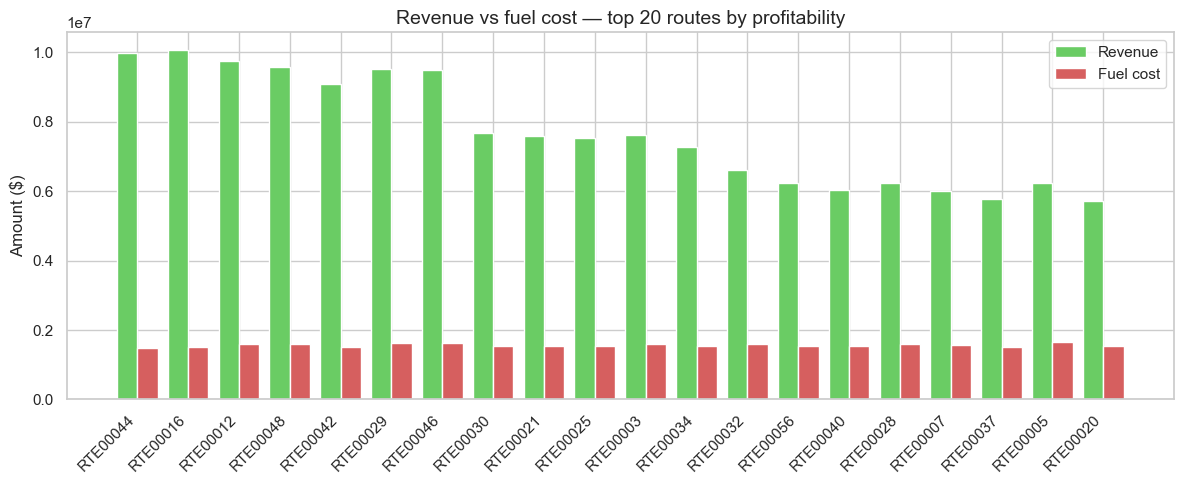

In [19]:
# Chart: Revenue vs fuel cost — top 20 routes
top20_routes = route_profit.head(20)

fig, ax = plt.subplots()
x = range(len(top20_routes))
width = 0.4

ax.bar([i - width/2 for i in x], top20_routes['total_revenue'],
       width=width, label='Revenue', color=sns.color_palette('muted')[2])
ax.bar([i + width/2 for i in x], top20_routes['total_fuel_cost'],
       width=width, label='Fuel cost', color=sns.color_palette('muted')[3])

ax.set_xticks(list(x))
ax.set_xticklabels(top20_routes['route_id'].astype(str), rotation=45, ha='right')
ax.set_ylabel('Amount ($)')
ax.set_title('Revenue vs fuel cost — top 20 routes by profitability')
ax.legend()
plt.tight_layout()
plt.savefig('../exports/chart_route_profitability.png', dpi=150)
plt.show()

In [ ]:
# Export route profitability summary
route_profit.to_csv(EXPORT_PATH + 'analysis_route_profitability.csv', index=False)
print('Exported: analysis_route_profitability.csv')

In [20]:
print('Trucks:', trucks.columns.tolist())

Trucks: ['truck_id', 'unit_number', 'make', 'model_year', 'vin', 'acquisition_date', 'acquisition_mileage', 'fuel_type', 'tank_capacity_gallons', 'status', 'home_terminal']


---
## Analysis 3 — Fleet Health

**Question:** Which trucks are underutilized or costing the most in maintenance?  
**Tables used:** `trucks` + `trips` + `maintenance` + `truck_metrics`

In [21]:
# Check maintenance columns
print('Maintenance columns:')
print(maintenance.columns.tolist())
print()
print(maintenance.head(3))

Maintenance columns:
['maintenance_id', 'truck_id', 'maintenance_date', 'maintenance_type', 'odometer_reading', 'labor_hours', 'labor_cost', 'parts_cost', 'total_cost', 'facility_location', 'downtime_hours', 'service_description']

  maintenance_id  truck_id maintenance_date maintenance_type  \
0  MAINT00000001  TRK00085       2022-01-01       Inspection   
1  MAINT00000002  TRK00041       2022-01-01             Tire   
2  MAINT00000003  TRK00090       2022-01-01       Preventive   

   odometer_reading  labor_hours  labor_cost  parts_cost  total_cost  \
0            400255         7.80      781.42       10.41      791.83   
1            268041         0.90       80.91    3,207.16    3,288.07   
2            698915         7.20      733.18    1,570.57    2,303.75   

  facility_location  downtime_hours   service_description  
0       Kansas City           22.20  Emergency Inspection  
1           Seattle            8.00        Scheduled Tire  
2             Miami           16.50    Rou

In [23]:
# Maintenance cost per truck
# Update column name if yours differs from total_cost
maint_by_truck = (
    maintenance
    .groupby('truck_id')
    .agg(
        total_maint_cost  = ('total_cost', 'sum'),
        maint_count       = ('maintenance_id', 'count')
    )
    .reset_index()
)

# Miles per truck from trips
miles_by_truck = (
    trips
    .groupby('truck_id')
    .agg(
        total_miles = ('actual_distance_miles', 'sum'),
        trip_count  = ('trip_id', 'count')
    )
    .reset_index()
)

# Combine
fleet_health = pd.merge(maint_by_truck, miles_by_truck, on='truck_id', how='inner')
fleet_health = pd.merge(fleet_health, trucks[['truck_id', 'make', 'model_year']], on='truck_id', how='left')

fleet_health['cost_per_mile'] = (
    fleet_health['total_maint_cost'] / fleet_health['total_miles']
).round(4)

fleet_health = fleet_health.sort_values('cost_per_mile', ascending=False)

print('Top 10 trucks by maintenance cost per mile:')
print(fleet_health[['truck_id', 'make', 'model_year',
                     'total_maint_cost', 'total_miles', 'cost_per_mile']].head(10).to_string(index=False))

Top 10 trucks by maintenance cost per mile:
truck_id          make  model_year  total_maint_cost  total_miles  cost_per_mile
TRK00040 International        2015         67,557.74      1127848           0.06
TRK00026 International        2021         70,708.48      1184331           0.06
TRK00014 International        2015         71,801.82      1205267           0.06
TRK00073          Mack        2016         76,573.99      1288610           0.06
TRK00099  Freightliner        2015         73,231.77      1247555           0.06
TRK00038 International        2015         68,989.14      1223350           0.06
TRK00033          Mack        2015         67,514.43      1200064           0.06
TRK00052  Freightliner        2015         63,757.21      1190370           0.05
TRK00044         Volvo        2015         69,825.23      1348644           0.05
TRK00071          Mack        2017         61,696.55      1227452           0.05


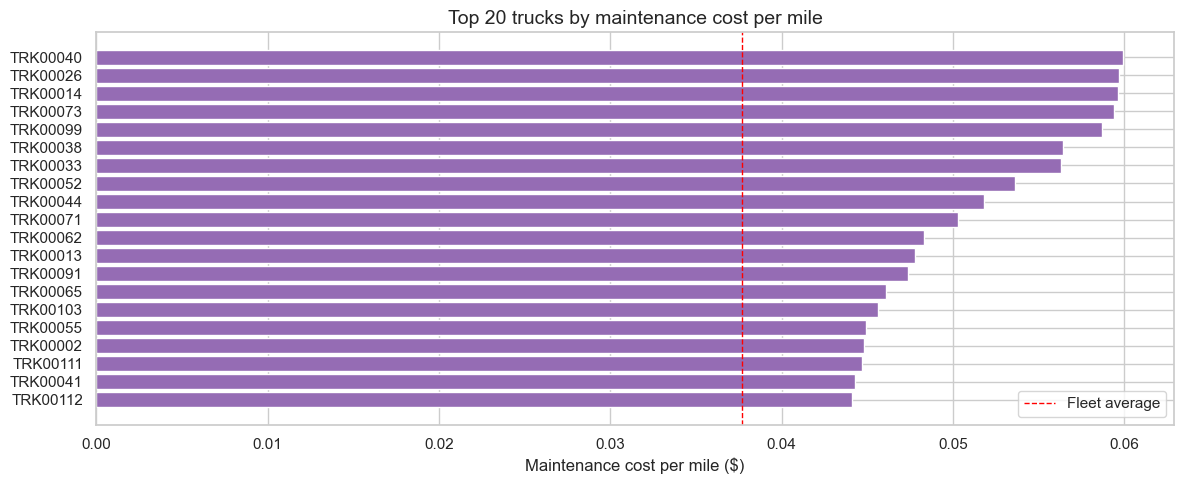


Fleet average maintenance cost per mile: $0.0377


In [24]:
# Chart: Maintenance cost per mile — top 20 trucks
top20_trucks = fleet_health.head(20)

fig, ax = plt.subplots()
ax.barh(
    top20_trucks['truck_id'].astype(str),
    top20_trucks['cost_per_mile'],
    color=sns.color_palette('muted')[4]
)
ax.set_xlabel('Maintenance cost per mile ($)')
ax.set_title('Top 20 trucks by maintenance cost per mile')
ax.axvline(x=fleet_health['cost_per_mile'].mean(), color='red',
           linestyle='--', linewidth=1, label='Fleet average')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../exports/chart_fleet_health.png', dpi=150)
plt.show()

print(f'\nFleet average maintenance cost per mile: ${fleet_health["cost_per_mile"].mean():.4f}')

In [27]:
route_profit.to_csv(EXPORT_PATH + 'analysis_route_profitability.csv', index=False)
print('Exported: analysis_route_profitability.csv')

Exported: analysis_route_profitability.csv


In [26]:
import os
files = sorted(os.listdir('../exports/'))
for f in files:
    print(f)

analysis_driver_performance.csv
analysis_fleet_health.csv
chart_driver_mpg.png
chart_driver_ontime.png
chart_fleet_health.png
chart_route_profitability.png
customers.csv
delivery_events.csv
driver_monthly_metrics.csv
drivers.csv
facilities.csv
fuel_purchases_clean.csv
loads.csv
maintenance_records.csv
placeholder.md
routes.csv
safety_incidents_clean.csv
trailers.csv
trips_clean.csv
truck_utilization_metrics.csv
trucks.csv


In [28]:
print('Best MPG driver:')
print(mpg_by_driver[['driver_id', 'avg_mpg']].head(1).to_string(index=False))

print('\nBest revenue/mile driver:')
print(rev_by_driver[['driver_id', 'revenue_per_mile']].head(1).to_string(index=False))

print('\nLeast profitable route:')
print(route_profit[['route_id', 'profit_margin']].tail(1).to_string(index=False))

print('\nAverage profit margin:', round(route_profit['profit_margin'].mean(), 1), '%')

print('\nHighest cost/mile truck:')
print(fleet_health[['truck_id', 'cost_per_mile']].head(1).to_string(index=False))

print('\nFleet average cost/mile:', round(fleet_health['cost_per_mile'].mean(), 4))

print('\nTotal maintenance spend: $', f"{maintenance['total_cost'].sum():,.2f}")

Best MPG driver:
driver_id  avg_mpg
 DRV00105     6.57

Best revenue/mile driver:
driver_id  revenue_per_mile
 DRV00101              2.21

Least profitable route:
route_id  profit_margin
RTE00010        -609.30

Average profit margin: 31.6 %

Highest cost/mile truck:
truck_id  cost_per_mile
TRK00040           0.06

Fleet average cost/mile: 0.0377

Total maintenance spend: $ 5,730,573.28


In [25]:
# Export fleet health summary
fleet_health.to_csv(EXPORT_PATH + 'analysis_fleet_health.csv', index=False)
print('Exported: analysis_fleet_health.csv')

Exported: analysis_fleet_health.csv


---
## 4. Key insights summary

Fill this in after running all cells above.

```
DRIVER PERFORMANCE
- Fleet average on-time rate:    55.7%
- Best performing driver:        DRV00108, on-time rate: 58.8%
- Best MPG driver:               DRV00105, MPG: 6.57
- Best revenue/mile driver:      DRV00101, $2.21/mile

ROUTE PROFITABILITY
- Most profitable route:         RTE00044, margin: 85.3%
- Least profitable route:        RTE00010, margin: -609.3% (losing money!)
- Average profit margin:         31.6%

FLEET HEALTH
- Highest cost/mile truck:       TRK00040, $0.06/mile
- Fleet average cost/mile:       $0.0377/mile
- Total maintenance spend:       $5,730,573.28
```

In [29]:
print('Best MPG driver:')
print(mpg_by_driver[['driver_id', 'avg_mpg']].head(1).to_string(index=False))

print('\nBest revenue/mile driver:')
print(rev_by_driver[['driver_id', 'revenue_per_mile']].head(1).to_string(index=False))

print('\nLeast profitable route:')
print(route_profit[['route_id', 'profit_margin']].tail(1).to_string(index=False))

print('\nAverage profit margin:', round(route_profit['profit_margin'].mean(), 1), '%')

print('\nHighest cost/mile truck:')
print(fleet_health[['truck_id', 'cost_per_mile']].head(1).to_string(index=False))

print('\nFleet average cost/mile:', round(fleet_health['cost_per_mile'].mean(), 4))

print('\nTotal maintenance spend: $', f"{maintenance['total_cost'].sum():,.2f}")

Best MPG driver:
driver_id  avg_mpg
 DRV00105     6.57

Best revenue/mile driver:
driver_id  revenue_per_mile
 DRV00101              2.21

Least profitable route:
route_id  profit_margin
RTE00010        -609.30

Average profit margin: 31.6 %

Highest cost/mile truck:
truck_id  cost_per_mile
TRK00040           0.06

Fleet average cost/mile: 0.0377

Total maintenance spend: $ 5,730,573.28


---
**Next step:** Open Tableau Public, connect to the `exports/` folder, and build the dashboard.  
Key files to connect:
- `analysis_driver_performance.csv`
- `analysis_route_profitability.csv`  
- `analysis_fleet_health.csv`

In [30]:
import os
print(os.getcwd())

/Users/taofeeksalami/logistics-analysis/notebooks
